In [1]:
import pyEDM
import pandas as pd
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt

random.seed(42)

p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)

In [2]:
# top 20 features from paper + target variable + one additional taxa as predictor
features = [
    "Lpoly_expected_ml", "Area", "Biovolume", "MajorAxisLength",
    "MinorAxisLength", "Perimeter", "Orientation", "Eccentricity",
    "Solidity", "texture_uniformity", "texture_smoothness",
    "texture_average_gray_level", "texture_entropy",
    "texture_average_contrast", "H90", "H180", "Hflip",
    "Extent", "EquivDiameter", "ConvexArea", "ConvexPerimeter",
    "Pmicans_expected_ml" # add another taxa as a predictor
]

target = "Lpoly_expected_ml"
predictors = [col for col in features if col != target]

# process images features for MVE
df = combined[["date"] + features].copy()
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df = df.sort_values("date").set_index("date")
df = df.asfreq("D")

# fill missing values using ema
df_filled = df.copy()
for col in features:
    ema = df[col].ewm(span=30, adjust=False).mean()
    df_filled[col] = df[col].fillna(ema)

# normalize features
df_norm = df_filled.copy()
for col in features:
    mu = df_filled[col].mean()
    sigma = df_filled[col].std()
    df_norm[col] = (df_filled[col] - mu) / sigma

df_mv = df_norm.copy()

In [3]:
# process environmental data
env = pd.read_csv("../data/environment_all.csv")

# could be relevant but too many missing values for ema imputation to be effective
env = env.drop(columns=[
    'fluorescent_dissolved_organic_matter_eco',
    'sea_water_turbidity_eco',
    'waterlevel_predicted_m',
    'mass_concentration_of_oxygen_in_sea_water_seaphox',
    'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water_seaphox',
    'fractional_saturation_of_oxygen_in_sea_water_seaphox',
    'sea_water_ph_reported_on_total_scale_seaphox_external'
])

env["date"] = pd.to_datetime(env["date"].astype(str), format="%Y%m%d")
env = env.sort_values("date").set_index("date")
env = env.asfreq("D")

env_features = env.columns.tolist()
env_filled = env.copy()

# fill missing values using ema
for col in env_features:
    ema = env[col].ewm(span=30, adjust=False).mean()
    env_filled[col] = env[col].fillna(ema)

# normalize features
df_norm = env_filled.copy()
for col in env_features:
    mu = env_filled[col].mean()
    sigma = env_filled[col].std()
    df_norm[col] = (env_filled[col] - mu) / sigma

df_env = df_norm.copy()

In [4]:
# align the two datasets on their common date range
common_start = max(df_mv.index.min(), df_env.index.min())
common_end = min(df_mv.index.max(), df_env.index.max())

df_mv = df_mv.loc[common_start:common_end]
df_env = df_env.loc[common_start:common_end]

df_all = df_mv.merge(df_env,left_index=True,right_index=True,how="inner")
df_all = df_all.reset_index()
df_all["t"] = np.arange(1, len(df_all) + 1)
df_all = df_all[["t"] + features + env_features]

df_mv = df_all[["t"] + features]
df_env = df_all[["t"] + env_features + [target]]

https://sugiharalab.github.io/EDM_Documentation/parameters/

In [5]:
def one_simplex(df, target, features, E, Tp):
    # Randomly select 3 features (+ the target) for the simplex projection
    chosen_features = random.sample(features, E-1)
    columns = [target] + chosen_features
    columns_str = " ".join(columns) # has to be 'space separated' idk ????

    N = len(df)
    res = pyEDM.Simplex(
        dataFrame=df,
        columns=columns_str,
        target=target,
        E=E,
        tau=1,
        Tp=Tp,
        lib=f"1 {N}",
        pred=f"1 {N}"
    )

    obs = res["Observations"].to_numpy()
    pred = res["Predictions"].to_numpy()

    mask = np.isfinite(obs) & np.isfinite(pred)
    obs = obs[mask]
    pred = pred[mask]

    if len(obs) < 10 or np.std(obs) == 0 or np.std(pred) == 0:
        return np.nan, chosen_features

    rho = np.corrcoef(obs, pred)[0, 1]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    mae = np.mean(np.abs(obs - pred))
    return rho, rmse, mae, chosen_features

def multiview_big(df, target, features, Tp, E, n_trials=500):
    results = []

    for i in range(n_trials):
        rho, rmse, mae, chosen = one_simplex(df, target, features, E, Tp=Tp)

        results.append({
            "rho": rho,
            "rmse": rmse,
            "mae": mae,
            "features": chosen
        })

    return pd.DataFrame(results)

def multiview_yes(df_mv, target, predictors, E, n_trials=500):
    # wrapper main function
    x = df_mv[target].to_numpy()

    summary_rows = []
    feature_importance_by_tp = {}
    
    for Tp in range(1, 32):
        mv = multiview_big(df_mv, target, predictors, Tp, E, n_trials)

        acf = abs(pd.Series(x).autocorr(lag=Tp))
        mv["rho_eff"] = mv["rho"] - acf

        # summary stats
        summary_rows.append({
            "Tp": Tp,
            "rho_mean": mv["rho"].mean(),
            "acf": acf,
            "rho_eff_mean": mv["rho_eff"].mean(),
            "rmse_mean": mv["rmse"].mean(),
            "mae_mean": mv["mae"].mean(),
            "n_models": len(mv)
        })

        # feature importance (top 5%)
        top = mv.nlargest(int(0.05 * len(mv)), "rho_eff")

        counts = Counter()
        for feats in top["features"]:
            for f in feats:
                counts[f] += 1

        importance = pd.Series(counts) / len(top)
        feature_importance_by_tp[Tp] = importance.sort_values(ascending=False)
    
    return summary_rows, feature_importance_by_tp

##### Image Features

In [6]:
summary_rows_img = []
feature_importance_by_tp_img = {}

summary_rows_img, feature_importance_by_tp_img = multiview_yes(df_mv, target, predictors, E=4, n_trials=500)
summary_df_img = pd.DataFrame(summary_rows_img)
print(summary_df_img)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.940135  0.750836      0.189300   0.439333  0.083295       500
1    2  0.949407  0.507478      0.441930   0.402746  0.078743       500
2    3  0.948128  0.363468      0.584661   0.377946  0.080308       500
3    4  0.594056  0.323560      0.270496   0.810557  0.181759       500
4    5  0.407290  0.282526      0.124765   0.945784  0.217034       500
5    6  0.365037  0.199548      0.165490   0.964105  0.225539       500
6    7  0.303833  0.162179      0.141655   0.982039  0.237566       500
7    8  0.239517  0.160931      0.078586   0.999675  0.240159       500
8    9  0.249507  0.149251      0.100256   0.998083  0.240002       500
9   10  0.253443  0.174992      0.078451   0.996177  0.243209       500
10  11  0.232610  0.157892      0.074718   1.004961  0.248176       500
11  12  0.198242  0.141327      0.056915   1.027203  0.266158       500
12  13  0.167349  0.147118      0.020231   1.045240  0.279247   

In [7]:
for E in [2, 3, 4, 5, 6]:
    summary, auh = multiview_yes(df_mv, target, predictors, E=E)
    summary_df = pd.DataFrame(summary)
    print(f"E={E}, mean rho_eff:", summary_df["rho_eff_mean"].mean())

E=2, mean rho_eff: 0.11418019701420752
E=3, mean rho_eff: 0.17525869110229636
E=4, mean rho_eff: 0.25226850886610225
E=5, mean rho_eff: 0.32191708937078556
E=6, mean rho_eff: 0.36709347352145555


In [8]:
importance_all_img = pd.concat(
    feature_importance_by_tp_img,
    names=["Tp", "Feature"]
).reset_index()

importance_all_img.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_img)

##### Environmental Features

In [9]:
summary_rows_env = []
feature_importance_by_tp_env = {}

summary_rows_env, feature_importance_by_tp_env = multiview_yes(df_env, target, env_features, E=4, n_trials=500)
summary_df_env = pd.DataFrame(summary_rows_env)
print(summary_df_env)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.931301  0.750836      0.180465   0.454445  0.117962       500
1    2  0.941270  0.507478      0.433792   0.421501  0.113551       500
2    3  0.938334  0.363468      0.574866   0.402811  0.114866       500
3    4  0.585389  0.323560      0.261829   0.816942  0.202836       500
4    5  0.407736  0.282526      0.125211   0.937684  0.229649       500
5    6  0.393565  0.199548      0.194017   0.939774  0.235961       500
6    7  0.420144  0.162179      0.257965   0.912532  0.235107       500
7    8  0.378563  0.160931      0.217632   0.928151  0.247015       500
8    9  0.404539  0.149251      0.255288   0.912738  0.245211       500
9   10  0.350856  0.174992      0.175865   0.948783  0.258333       500
10  11  0.303898  0.157892      0.146006   0.980852  0.268000       500
11  12  0.273079  0.141327      0.131752   1.008497  0.278728       500
12  13  0.238766  0.147118      0.091649   1.020722  0.289311   

In [10]:
importance_all_env = pd.concat(
    feature_importance_by_tp_env,
    names=["Tp", "Feature"]
).reset_index()

importance_all_env.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_env)

##### Combined

In [11]:
summary_rows_com = []
feature_importance_by_tp_com = {}

summary_rows_com, feature_importance_by_tp_com = multiview_yes(df_all, target, predictors+env_features, E=4, n_trials=500)
summary_df_com = pd.DataFrame(summary_rows_com)
print(summary_df_com)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.936612  0.750836      0.185776   0.444760  0.094116       500
1    2  0.946205  0.507478      0.438727   0.409490  0.088682       500
2    3  0.944517  0.363468      0.581049   0.386839  0.091171       500
3    4  0.585924  0.323560      0.262364   0.817188  0.188137       500
4    5  0.399881  0.282526      0.117356   0.948461  0.220897       500
5    6  0.360183  0.199548      0.160636   0.963448  0.227542       500
6    7  0.329831  0.162179      0.167652   0.967488  0.234292       500
7    8  0.262916  0.160931      0.101985   0.990335  0.240877       500
8    9  0.281713  0.149251      0.132462   0.980080  0.237776       500
9   10  0.280234  0.174992      0.105243   0.982719  0.241880       500
10  11  0.268491  0.157892      0.110599   0.988650  0.245731       500
11  12  0.259756  0.141327      0.118429   0.999129  0.260537       500
12  13  0.246077  0.147118      0.098959   1.004881  0.268444   

In [12]:
importance_all_com = pd.concat(
    feature_importance_by_tp_com,
    names=["Tp", "Feature"]
).reset_index()

importance_all_com.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_com)

In [13]:
def plot_tp(df, metric, ylabel, title,color="#0d7c8e",figsize=(3.5, 2)):
    plt.figure(figsize=figsize)
    plt.plot(df["Tp"], df[metric],marker="o",color=color)
    
    plt.xlabel("Prediction Interval (Tp)", fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.title(title, fontsize=10)

    plt.show()

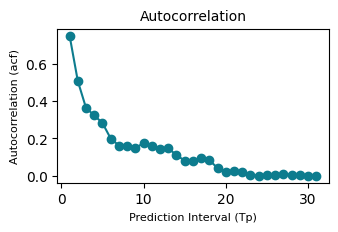

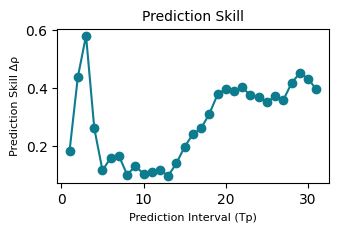

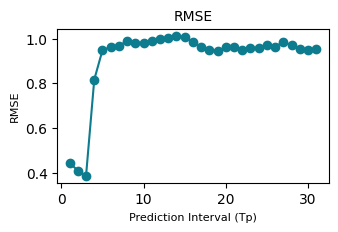

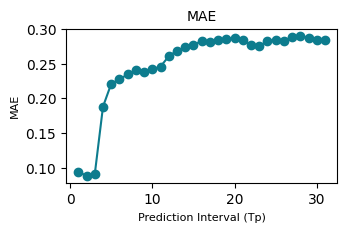

In [14]:
plot_tp(summary_df_com,"acf","Autocorrelation (acf)","Autocorrelation")
plot_tp(summary_df_com,"rho_eff_mean","Prediction Skill Δρ","Prediction Skill")
plot_tp(summary_df_com,"rmse_mean","RMSE","RMSE")
plot_tp(summary_df_com,"mae_mean","MAE","MAE")

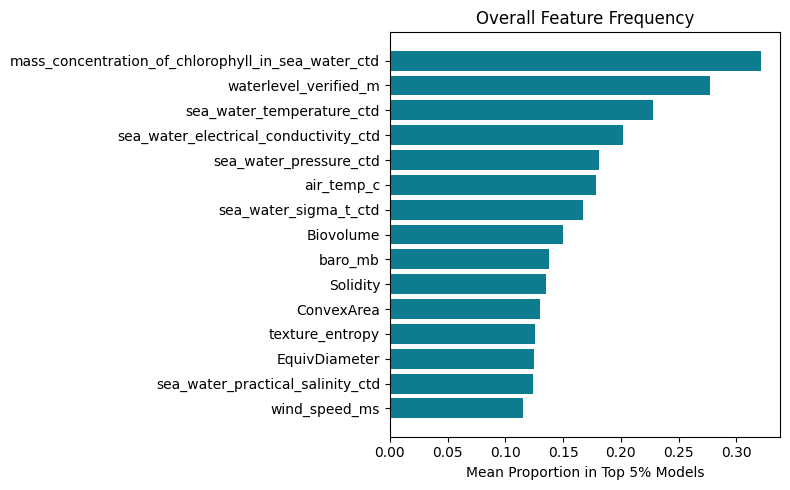

In [15]:
mean_importance = (
    importance_all_com
    .groupby("Feature")["Proportion"]
    .mean()
    .sort_values(ascending=False)
)

top_plot = mean_importance.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top_plot.index, top_plot.values, color="#0d7c8e")
plt.xlabel("Mean Proportion in Top 5% Models")
plt.title("Overall Feature Frequency")
plt.tight_layout()
plt.show()

^^ using combined

### test prediction of different algae

In [16]:
summary_rows_pmicans = []
feature_importance_by_tp_pmicans = {}

summary_rows_pmicans, feature_importance_by_pmicans = multiview_yes(df_all, "Pmicans_expected_ml", predictors+env_features, E=4, n_trials=500)
summary_df_pmicans = pd.DataFrame(summary_rows_pmicans)
print(summary_df_pmicans)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.947094  0.846651      0.100443   0.339203  0.113419       500
1    2  0.944773  0.739771      0.205001   0.344598  0.112020       500
2    3  0.938563  0.711495      0.227068   0.357732  0.116206       500
3    4  0.834969  0.670782      0.164187   0.558445  0.181876       500
4    5  0.802457  0.633032      0.169426   0.607391  0.199913       500
5    6  0.786503  0.640761      0.145742   0.622198  0.213083       500
6    7  0.772490  0.658776      0.113713   0.638795  0.220697       500
7    8  0.746640  0.623247      0.123394   0.671250  0.228698       500
8    9  0.740755  0.582937      0.157818   0.678486  0.234232       500
9   10  0.706253  0.560913      0.145341   0.714184  0.241850       500
10  11  0.658291  0.568219      0.090071   0.758236  0.252586       500
11  12  0.634099  0.555586      0.078512   0.777708  0.262918       500
12  13  0.599404  0.510024      0.089380   0.810451  0.276564   

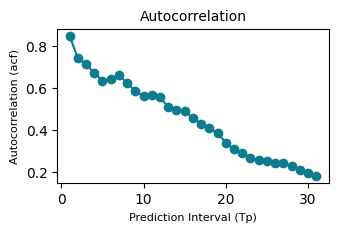

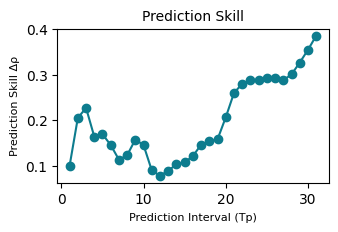

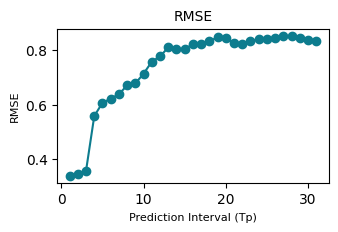

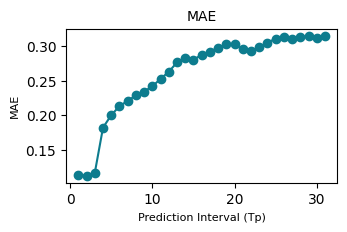

In [17]:
plot_tp(summary_df_pmicans,"acf","Autocorrelation (acf)","Autocorrelation")
plot_tp(summary_df_pmicans,"rho_eff_mean","Prediction Skill Δρ","Prediction Skill")
plot_tp(summary_df_pmicans,"rmse_mean","RMSE","RMSE")
plot_tp(summary_df_pmicans,"mae_mean","MAE","MAE")

In [18]:
# def plot_forecast_summary(df, color="#0d7c8e"):
    
#     metrics = [
#         ("acf", "Autocorrelation"),
#         ("rho_eff_mean", "Prediction Skill Δρ"),
#         ("rmse_mean", "RMSE"),
#         ("mae_mean", "MAE")
#     ]
    
#     fig, axes = plt.subplots(2, 2, figsize=(7, 4))
#     axes = axes.flatten()
    
#     for ax, (metric, title) in zip(axes, metrics):
#         ax.plot(df["Tp"], df[metric], marker="o", color=color)
#         ax.set_title(title, fontsize=9)
#         ax.set_xlabel("Tp", fontsize=8)
#         ax.tick_params(labelsize=7)
    
#     plt.tight_layout()
#     plt.show()

# plot_forecast_summary(summary_df_com)

#### with higher embedding dimension
could be overfitting idk

In [19]:
summary_rows_com = []
feature_importance_by_tp_com = {}

summary_rows_com, feature_importance_by_tp_com = multiview_yes(df_all, target, predictors+env_features, E=6, n_trials=800)
summary_df_com = pd.DataFrame(summary_rows_com)
print(summary_df_com)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.920402  0.750836      0.169567   0.539937  0.119584       800
1    2  0.928754  0.507478      0.421276   0.514357  0.114301       800
2    3  0.926230  0.363468      0.562762   0.500148  0.110652       800
3    4  0.931546  0.323560      0.607986   0.493774  0.111945       800
4    5  0.944349  0.282526      0.661824   0.457421  0.113032       800
5    6  0.658246  0.199548      0.458698   0.758188  0.180101       800
6    7  0.486963  0.162179      0.324784   0.880660  0.205611       800
7    8  0.397100  0.160931      0.236169   0.929863  0.212313       800
8    9  0.360946  0.149251      0.211694   0.943753  0.215753       800
9   10  0.338552  0.174992      0.163560   0.952063  0.221955       800
10  11  0.328580  0.157892      0.170687   0.954190  0.223270       800
11  12  0.331745  0.141327      0.190418   0.952252  0.221530       800
12  13  0.359472  0.147118      0.212354   0.941546  0.227764   

In [20]:
importance_all_com = pd.concat(
    feature_importance_by_tp_com,
    names=["Tp", "Feature"]
).reset_index()

importance_all_com.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_com)

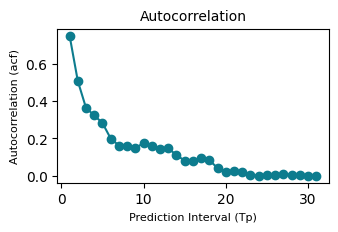

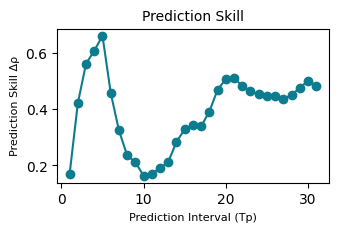

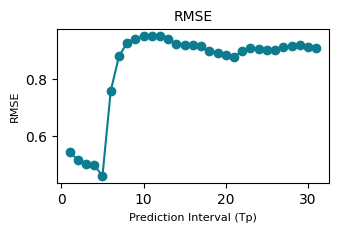

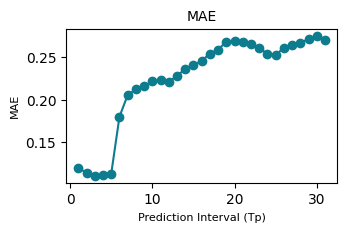

In [21]:
plot_tp(summary_df_com,"acf","Autocorrelation (acf)","Autocorrelation")
plot_tp(summary_df_com,"rho_eff_mean","Prediction Skill Δρ","Prediction Skill")
plot_tp(summary_df_com,"rmse_mean","RMSE","RMSE")
plot_tp(summary_df_com,"mae_mean","MAE","MAE")

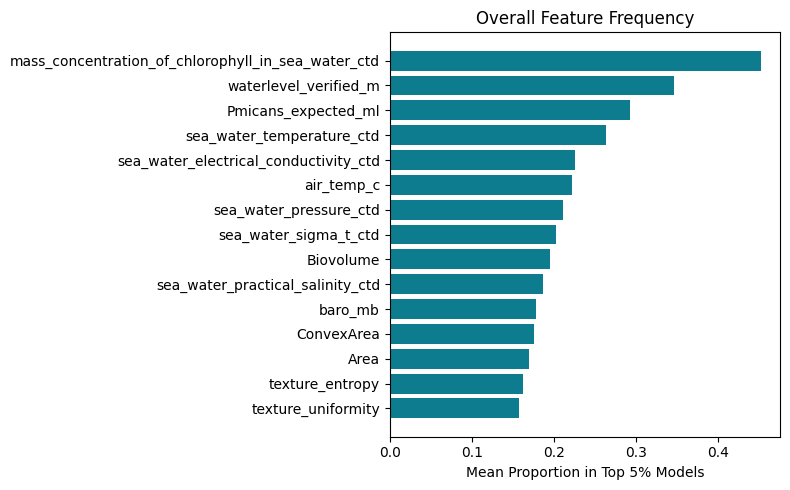

In [22]:
mean_importance = (
    importance_all_com
    .groupby("Feature")["Proportion"]
    .mean()
    .sort_values(ascending=False)
)

top_plot = mean_importance.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top_plot.index, top_plot.values, color="#0d7c8e")
plt.xlabel("Mean Proportion in Top 5% Models")
plt.title("Overall Feature Frequency")
plt.tight_layout()
plt.show()